In [ ]:
!pip install torch-geometric

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train_features.csv to train_features.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_features.csv to test_features.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Train_adjacency_matrix.csv to Train_adjacency_matrix.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Test_adjacency_matrix.csv to Test_adjacency_matrix.csv


In [ ]:
import torch
import pandas as pd
import numpy as np

In [ ]:
# Load adjacency matrices
adj_train = pd.read_csv("Train_adjacency_matrix.csv", index_col=0)
adj_test = pd.read_csv("Test_adjacency_matrix.csv", index_col=0)

# Load feature matrices
X_train = pd.read_csv("train_features.csv", index_col=0)
X_test = pd.read_csv("test_features.csv", index_col=0)

In [ ]:
print("Train Adjacency Shape:", adj_train.shape)
print("Test Adjacency Shape:", adj_test.shape)

print("\nTrain Features Shape:", X_train.shape)
print("Test Features Shape:", X_test.shape)

Train Adjacency Shape: (326, 326)
Test Adjacency Shape: (193, 193)

Train Features Shape: (326, 253)
Test Features Shape: (193, 173)


In [ ]:
# Convert to numeric
adj_train = adj_train.apply(pd.to_numeric)
adj_test = adj_test.apply(pd.to_numeric)

X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)

# Remove self-loops
np.fill_diagonal(adj_train.values, 0)
np.fill_diagonal(adj_test.values, 0)

In [ ]:
# Ensure same node order
# Find common feature columns
common_cols = X_train.columns.intersection(X_test.columns)

# Keep only common columns
X_train = X_train[common_cols]
X_test = X_test[common_cols]

In [ ]:
X_train = X_train.loc[adj_train.index]
X_test = X_test.loc[adj_test.index]

In [ ]:
print("\nAfter Feature Alignment:")
print("Train Features Shape:", X_train.shape)
print("Test Features Shape:", X_test.shape)

print("\nCommon Feature Columns:", len(common_cols))


After Feature Alignment:
Train Features Shape: (470, 173)
Test Features Shape: (249, 173)

Common Feature Columns: 173


In [ ]:
# Train edges
train_edges = np.array(np.where(adj_train.values > 0)).T
train_edge_index = torch.tensor(train_edges.T, dtype=torch.long)

# Test edges
test_edges = np.array(np.where(adj_test.values > 0)).T
test_edge_index = torch.tensor(test_edges.T, dtype=torch.long)

In [ ]:
def generate_negative_edges(adj):
    adj_np = adj.values
    n = adj_np.shape[0]

    all_pairs = np.array(np.where(np.triu(np.ones((n, n)), k=1))).T
    mask = adj_np[all_pairs[:, 0], all_pairs[:, 1]] == 0

    neg_candidates = all_pairs[mask]

    num_pos = np.sum(adj_np > 0)
    num_neg = min(len(neg_candidates), num_pos)

    replace_flag = len(neg_candidates) < num_neg

    idx = np.random.choice(len(neg_candidates), num_neg, replace=replace_flag)
    neg_edges = neg_candidates[idx]

    return torch.tensor(neg_edges.T, dtype=torch.long)

In [ ]:
# Train negatives
train_neg_edge_index = generate_negative_edges(adj_train)

train_edge_index_full = torch.cat([train_edge_index, train_neg_edge_index], dim=1)
train_labels = torch.cat([
    torch.ones(train_edge_index.shape[1]),
    torch.zeros(train_neg_edge_index.shape[1])
])

# Test negatives
test_neg_edge_index = generate_negative_edges(adj_test)

test_edge_index_full = torch.cat([test_edge_index, test_neg_edge_index], dim=1)
test_labels = torch.cat([
    torch.ones(test_edge_index.shape[1]),
    torch.zeros(test_neg_edge_index.shape[1])
])

In [ ]:
print("\nTrain Total Edges:", train_edge_index_full.shape)
print("Train Labels:", train_labels.shape)

print("\nTest Total Edges:", test_edge_index_full.shape)
print("Test Labels:", test_labels.shape)

# Check balance
print("\nTrain Pos:", (train_labels == 1).sum().item())
print("Train Neg:", (train_labels == 0).sum().item())


Train Total Edges: torch.Size([2, 87220])
Train Labels: torch.Size([87220])

Test Total Edges: torch.Size([2, 32297])
Test Labels: torch.Size([32297])

Train Pos: 68490
Train Neg: 18730


In [ ]:
train_features = torch.tensor(X_train.values, dtype=torch.float32)
test_features = torch.tensor(X_test.values, dtype=torch.float32)

In [ ]:
print("\nTrain Feature Tensor Shape:", train_features.shape)
print(train_features[:2])

print("\n")
print("\nTest Feature Tensor Shape:", test_features.shape)
print(test_features[:2])


Train Feature Tensor Shape: torch.Size([470, 173])
tensor([[0.7623, 0.6578, 0.0216, 0.0031, 0.0213, 0.0000, 0.0485, 0.6953, 0.5879,
         0.5989, 0.7222, 0.6378, 0.5454, 0.5357, 0.6245, 0.6451, 0.5869, 0.5973,
         0.0178, 0.8972, 0.5153, 0.6448, 0.6719, 0.5988, 0.6434, 0.6768, 0.5141,
         0.5513, 0.6341, 0.7059, 0.6326, 0.6402, 0.6440, 0.5665, 0.6267, 0.6149,
         0.6468, 0.6774, 0.7060, 0.5671, 0.6312, 0.6705, 0.6979, 0.5966, 0.6758,
         0.6555, 0.6868, 0.5730, 0.5435, 0.5729, 0.6172, 0.6919, 0.6159, 0.5685,
         0.7496, 0.7165, 0.5489, 0.7226, 0.6662, 0.5402, 0.0160, 0.8982, 0.6737,
         0.6533, 0.5586, 0.5187, 0.6694, 0.6618, 0.5711, 0.5736, 0.6953, 0.5697,
         0.5427, 0.5699, 0.6851, 0.7077, 0.5625, 0.5557, 0.7210, 0.5593, 0.6974,
         0.6810, 0.5951, 1.0000, 0.8062, 0.6367, 0.5848, 0.7825, 0.5790, 0.6055,
         0.8222, 0.6114, 0.7956, 0.6392, 0.5478, 0.5823, 0.7293, 0.5337, 0.7319,
         0.6152, 0.5768, 0.5520, 0.7169, 0.7039, 0.5499, 

In [ ]:
mean = train_features.mean(dim=0)
std = train_features.std(dim=0) + 1e-8

train_features = (train_features - mean) / std
test_features = (test_features - mean) / std

In [ ]:
print("\nAfter Normalization:")

print("Train Mean (approx 0):", train_features.mean().item())
print("Train Std (approx 1):", train_features.std().item())

print("Test Mean:", test_features.mean().item())
print("Test Std:", test_features.std().item())


After Normalization:
Train Mean (approx 0): 1.032140484191757e-09
Train Std (approx 1): 0.9989416599273682
Test Mean: 0.2030230462551117
Test Std: 1.0138697624206543


In [ ]:
print("Train Edge Index:", train_edge_index_full.shape)
print("Test Edge Index:", test_edge_index_full.shape)

print("\n")
print("Train Features:", train_features.shape)
print("Test Features:", test_features.shape)

print("\n")
print("Train Labels:", train_labels.shape)
print("Test Labels:", test_labels.shape)

Train Edge Index: torch.Size([2, 87220])
Test Edge Index: torch.Size([2, 32297])


Train Features: torch.Size([470, 173])
Test Features: torch.Size([249, 173])


Train Labels: torch.Size([87220])
Test Labels: torch.Size([32297])


In [ ]:
def create_edge_data(adj_matrix):
    adj_np = adj_matrix.values
    num_nodes = adj_np.shape[0]

    pos_edge_indices = np.array(np.where(np.triu(adj_np, k=1) > 0)).T
    pos_edge_index = torch.tensor(pos_edge_indices.T, dtype=torch.long)

    all_pairs = np.array(np.where(np.triu(np.ones_like(adj_np), k=1))).T
    neg_candidates = all_pairs[adj_np[all_pairs[:, 0], all_pairs[:, 1]] == 0]

    num_pos = pos_edge_index.shape[1]
    num_neg = min(len(neg_candidates), num_pos)

    idx = np.random.choice(len(neg_candidates), num_neg, replace=False)
    neg_edge_index = torch.tensor(neg_candidates[idx].T, dtype=torch.long)

    pos_labels = torch.ones(num_pos)
    neg_labels = torch.zeros(num_neg)

    edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
    labels = torch.cat([pos_labels, neg_labels])

    return edge_index, labels, pos_edge_index

In [ ]:
train_edge_index, train_labels, train_pos_edges = create_edge_data(adj_train)
test_edge_index, test_labels, test_pos_edges = create_edge_data(adj_test)

In [ ]:
print("TRAIN/TEST EDGE SUMMARY")
print("Train edges (pos + neg):", train_edge_index.shape)
print("Train labels:", train_labels.shape)
print("Test edges (pos + neg):", test_edge_index.shape)
print("Test labels:", test_labels.shape)

print("Train positive edges:", train_pos_edges.shape)
print("Test positive edges:", test_pos_edges.shape)

TRAIN/TEST EDGE SUMMARY
Train edges (pos + neg): torch.Size([2, 52975])
Train labels: torch.Size([52975])
Test edges (pos + neg): torch.Size([2, 18528])
Test labels: torch.Size([18528])
Train positive edges: torch.Size([2, 34245])
Test positive edges: torch.Size([2, 13769])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class ImprovedGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.4):
        super(ImprovedGCN, self).__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels // 2)
        self.conv3 = GCNConv(hidden_channels // 2, out_channels)

        self.batch_norm1 = nn.BatchNorm1d(hidden_channels)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels // 2)

        self.edge_predictor = nn.Bilinear(out_channels, out_channels, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, graph_edge_index, edge_pairs):
        x = self.conv1(x, graph_edge_index)
        x = self.batch_norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, graph_edge_index)
        x = self.batch_norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, graph_edge_index)

        src, tgt = edge_pairs
        edge_scores = self.edge_predictor(x[src], x[tgt]).squeeze(1)
        return edge_scores

In [ ]:
x_train = torch.tensor(X_train.values, dtype=torch.float).to(device)
x_test = torch.tensor(X_test.values, dtype=torch.float).to(device)

x = x_train

train_edge_index = train_edge_index.to(device)
train_labels = train_labels.to(device)

test_edge_index = test_edge_index.to(device)
test_labels = test_labels.to(device)

train_graph_edges = train_pos_edges.to(device)
test_graph_edges = test_pos_edges.to(device)

model = ImprovedGCN(
    in_channels=x.shape[1],
    hidden_channels=128,
    out_channels=64
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.01, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=15, factor=0.5
)

loss_fn = nn.BCEWithLogitsLoss()

In [ ]:
def sample_edges(edge_index, edge_labels):
    """
    Sample equal number of positive and negative edges for balanced training.
    """
    pos_edges = edge_index[:, edge_labels == 1]
    neg_edges = edge_index[:, edge_labels == 0]

    num_samples = min(pos_edges.shape[1], neg_edges.shape[1])

    # Random sampling
    perm_pos = torch.randperm(pos_edges.shape[1], device=edge_index.device)[:num_samples]
    perm_neg = torch.randperm(neg_edges.shape[1], device=edge_index.device)[:num_samples]

    pos_sampled = pos_edges[:, perm_pos]
    neg_sampled = neg_edges[:, perm_neg]

    edges = torch.cat([pos_sampled, neg_sampled], dim=1)
    labels = torch.cat([torch.ones(num_samples, device=edge_index.device),
                        torch.zeros(num_samples, device=edge_index.device)])

    # Shuffle
    perm = torch.randperm(edges.shape[1], device=edge_index.device)
    edges = edges[:, perm]
    labels = labels[perm]

    return edges, labels

In [ ]:
def evaluate(pred, labels, threshold=0.5):
    pred_probs = torch.sigmoid(pred).detach().cpu().numpy()
    pred_labels = (pred_probs > threshold).astype(int)
    labels = labels.cpu().numpy()

    auc = roc_auc_score(labels, pred_probs)
    pr_auc = average_precision_score(labels, pred_probs)
    acc = accuracy_score(labels, pred_labels)
    f1 = f1_score(labels, pred_labels)
    precision = precision_score(labels, pred_labels)
    recall = recall_score(labels, pred_labels)

    tn, fp, fn, tp = confusion_matrix(labels, pred_labels).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return auc, pr_auc, acc, f1, precision, recall, sensitivity, specificity

In [ ]:
epochs = 300
losses, auc_scores = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Sample edges for balanced training
    sampled_edges, sampled_labels = sample_edges(train_edge_index, train_labels)

    # Forward pass
    preds = model(x, train_graph_edges.to(device), sampled_edges)

    # Loss
    loss = loss_fn(preds, sampled_labels)
    loss.backward()

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    # Evaluate periodically
    if (epoch + 1) % 50 == 0:
        model.eval()
        with torch.no_grad():
            auc, pr_auc, acc, f1, precision, recall, sensitivity, specificity = evaluate(
                preds, sampled_labels
            )
            print(f"Epoch {epoch+1}: Loss={loss.item():.4f}, AUC={auc:.4f}, PR-AUC={pr_auc:.4f}, "
                  f"Acc={acc:.4f}, F1={f1:.4f}, Precision={precision:.4f}, Recall={recall:.4f}, "
                  f"Sensitivity={sensitivity:.4f}, Specificity={specificity:.4f}")

        losses.append(loss.item())
        auc_scores.append(auc)
        scheduler.step(auc)

Epoch 50: Loss=0.5015, AUC=0.9292, PR-AUC=0.9156, Acc=0.7569, F1=0.6962, Precision=0.9276, Recall=0.5572, Sensitivity=0.5572, Specificity=0.9565
Epoch 100: Loss=0.2986, AUC=0.9732, PR-AUC=0.9649, Acc=0.9068, F1=0.9145, Precision=0.8443, Recall=0.9975, Sensitivity=0.9975, Specificity=0.8160
Epoch 150: Loss=0.2020, AUC=0.9839, PR-AUC=0.9798, Acc=0.9223, F1=0.9276, Precision=0.8678, Recall=0.9963, Sensitivity=0.9963, Specificity=0.8483
Epoch 200: Loss=0.2011, AUC=0.9818, PR-AUC=0.9805, Acc=0.9255, F1=0.9283, Precision=0.8949, Recall=0.9643, Sensitivity=0.9643, Specificity=0.8867
Epoch 250: Loss=0.1930, AUC=0.9788, PR-AUC=0.9776, Acc=0.9183, F1=0.9207, Precision=0.8942, Recall=0.9488, Sensitivity=0.9488, Specificity=0.8877
Epoch 300: Loss=0.1624, AUC=0.9865, PR-AUC=0.9860, Acc=0.9377, F1=0.9396, Precision=0.9114, Recall=0.9696, Sensitivity=0.9696, Specificity=0.9057


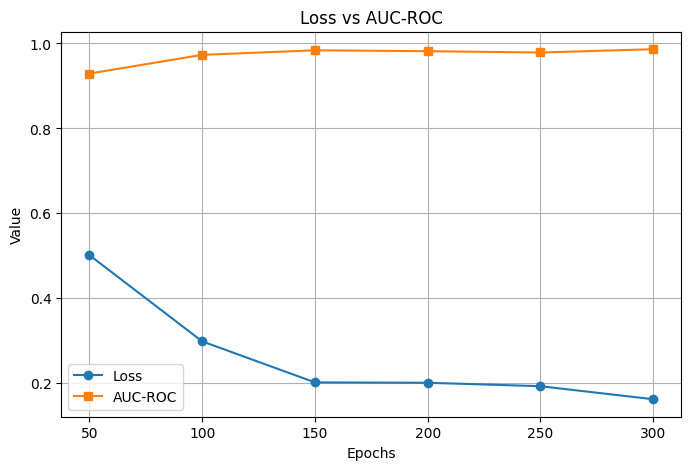

In [ ]:
import matplotlib.pyplot as plt

# X-axis (epochs where evaluation happened)
epochs_recorded = list(range(50, epochs + 1, 50))

plt.figure(figsize=(8, 5))

# Plot Loss
plt.plot(epochs_recorded, losses, marker='o', label='Loss')

# Plot AUC-ROC
plt.plot(epochs_recorded, auc_scores, marker='s', label='AUC-ROC')

plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Loss vs AUC-ROC')
plt.legend()
plt.grid(True)

plt.savefig("loss_vs_auc.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import networkx as nx
import pandas as pd
import torch

G = nx.Graph()

gene_ids = X_train.index.tolist()

G.add_nodes_from(gene_ids)

threshold = 0.5
edge_scores = []
predicted_edges = []

with torch.no_grad():
    probs = torch.sigmoid(
        model(x, train_graph_edges, test_edge_index)
    ).cpu().numpy()

for i in range(test_edge_index.shape[1]):
    node1, node2 = test_edge_index[:, i].cpu().numpy()
    gene1, gene2 = gene_ids[node1], gene_ids[node2]
    score = probs[i]

    G.add_edge(gene1, gene2, weight=score)
    edge_scores.append((gene1, gene2, score))

    if score > threshold:
        predicted_edges.append((gene1, gene2))

edge_scores_df = pd.DataFrame(edge_scores, columns=["Gene1", "Gene2", "Score"])
edge_scores_df = edge_scores_df.sort_values(by="Score", ascending=False)

top_edges = edge_scores_df.head(20)

print("\nTop 20 Predicted Gene Interactions:")
print(top_edges)

#edge_scores_df.to_csv("Top_Predicted_Gene_Interactions.csv", index=False)

gene_importance = dict(G.degree(weight='weight'))

gene_df = pd.DataFrame(list(gene_importance.items()), columns=["Gene", "Importance"])

top_genes = gene_df.sort_values(by="Importance", ascending=False).head(20)

print("\nTop 20 Genes:")
print(top_genes)


Top 20 Predicted Gene Interactions:
         Gene1    Gene2  Score
13299   HOXA13     ESR2    1.0
18469  NEUROG1     ESR2    1.0
18491     LHX4    FOXK1    1.0
12582    HNF1A    ESRRB    1.0
12581    HNF1A   HOXA13    1.0
12580    HNF1A   HOXA13    1.0
12578    HNF1A     RBSN    1.0
12575    HNF1A  ZSCAN30    1.0
12573    HNF1A     IRF4    1.0
12572    HNF1A     BNC1    1.0
12571    HNF1A     PAX9    1.0
12570    HNF1A     PAX9    1.0
12569    HNF1A    ZFP90    1.0
12602    HNF1A     USF3    1.0
12599    HNF1A     ESR2    1.0
12597    HNF1A     ESR2    1.0
12596    HNF1A    TCF21    1.0
12565    HNF1A     PAX3    1.0
12564    HNF1A     PAX3    1.0
13326    ESRRB    TCF21    1.0

Top 20 Genes:
        Gene  Importance
97      PAX9   76.658684
114    SNAI3   76.178474
105    FOXK1   75.810814
107    ESRRB   75.157677
117   ZNF578   75.015465
66      PAX3   74.894867
94     PRDM5   74.271263
100  ZSCAN30   74.008209
98      BNC1   73.854355
93     HNF1A   73.800484
112    NR1I2   73.6223

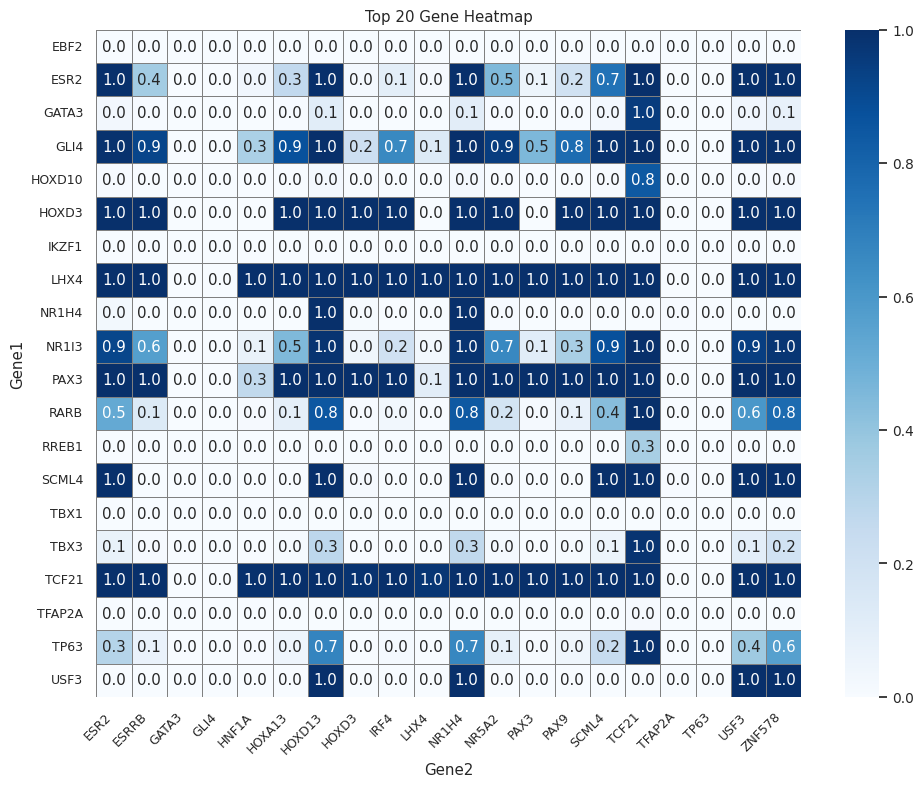

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select top N genes
top_n = 20
top_gene_list = top_genes[:top_n]

# Filter edges for top genes only
top_edges_df = edge_scores_df[
    edge_scores_df['Gene1'].isin(top_gene_list) &
    edge_scores_df['Gene2'].isin(top_gene_list)
]

# Create square matrix for top genes
matrix_size = len(top_gene_list)
interaction_matrix = np.zeros((matrix_size, matrix_size))
gene_index = {gene: i for i, gene in enumerate(top_gene_list)}

# Fill matrix with scores
for _, row in top_edges_df.iterrows():
    i = gene_index[row['Gene1']]
    j = gene_index[row['Gene2']]
    interaction_matrix[i, j] = row['Score']
    interaction_matrix[j, i] = row['Score']  # symmetrical

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(interaction_matrix, xticklabels=top_gene_list, yticklabels=top_gene_list,
            cmap="YlGnBu", annot=True, fmt=".2f", cbar_kws={'label': 'Interaction Score'})
plt.title("Top 20 Gene-Gene Interaction Heatmap", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

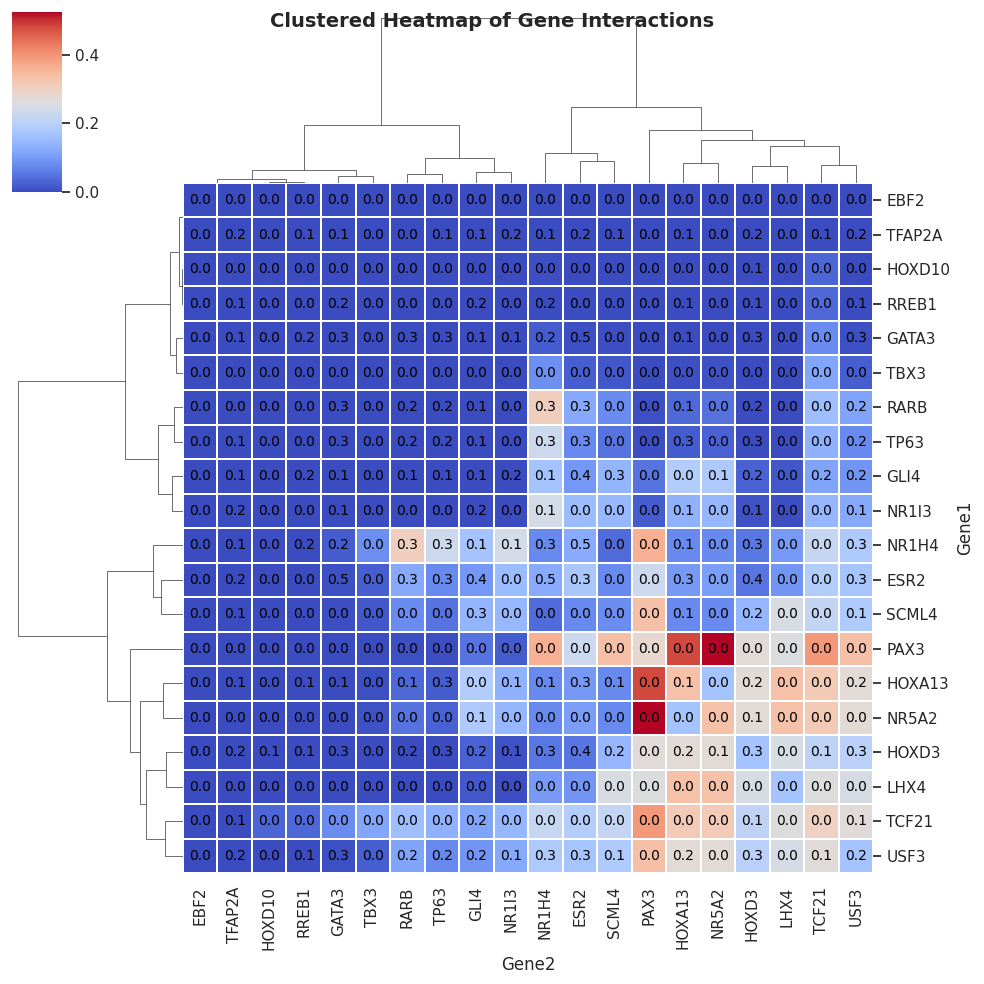

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# # -----------------------------
# 1. Load your dataset
# -----------------------------
# Example:
edge_scores_df = pd.read_csv("Top_Predicted_Gene_Interactions.csv")
# -----------------------------
edge_scores_df = edge_scores_df.drop_duplicates()

all_genes = pd.concat([edge_scores_df['Gene1'], edge_scores_df['Gene2']])
top_gene_list = all_genes.value_counts().head(20).index.tolist()

df = edge_scores_df[
    edge_scores_df['Gene1'].isin(top_gene_list) &
    edge_scores_df['Gene2'].isin(top_gene_list)
]

# Make symmetric
df_swapped = df.rename(columns={'Gene1': 'Gene2', 'Gene2': 'Gene1'})
df = pd.concat([df, df_swapped])

# Create matrix
heatmap_data = df.pivot_table(
    index='Gene1',
    columns='Gene2',
    values='Score',
    aggfunc='mean',
    fill_value=0
)

# -----------------------------
# 2. Cluster Heatmap
# -----------------------------
sns.set(style="white")

g = sns.clustermap(
    heatmap_data,
    cmap='coolwarm',
    figsize=(10, 10),
    linewidths=0.3,
    method='ward',
    metric='euclidean'
)

# -----------------------------
# 3. Add numbers manually
# -----------------------------
ax = g.ax_heatmap

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(
            j + 0.5,
            i + 0.5,
            f"{heatmap_data.iloc[i, j]:.1f}",
            ha='center',
            va='center',
            fontsize=10,
            color='black'
        )

plt.suptitle('Clustered Heatmap of Gene Interactions',
             fontsize=14, weight='bold')

plt.show()